In [22]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# 1. Load dataset
data = load_iris()
X, y = data.data, data.target

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X, y

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

In [23]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=2)

X_lowered = pca.fit_transform(X_train_scaled)

X_lowered

array([[-2.35430673, -1.03369922],
       [ 0.32811646, -1.48461375],
       [ 1.2290844 , -0.08852476],
       [-2.19452009, -0.41449679],
       [ 0.24248823, -1.27773347],
       [ 1.52294955, -0.87749328],
       [ 0.25815436, -0.81456565],
       [ 1.08813566, -0.28307828],
       [ 2.7816565 ,  0.80260248],
       [ 2.45214546,  2.47719638],
       [ 2.73500972,  0.75120347],
       [ 0.64451798, -0.20768998],
       [-0.17735004, -2.56577792],
       [ 0.12752389, -0.75913868],
       [ 0.30008117, -0.95247461],
       [-2.26948632, -0.27811494],
       [-2.31638839,  1.1510026 ],
       [ 1.96442486, -0.70771473],
       [ 1.33662596,  0.41860613],
       [-1.82655915,  0.44737164],
       [ 1.19203651, -0.91394324],
       [-2.35781737,  1.14379899],
       [ 2.32990455,  2.53829986],
       [-1.96744528, -0.57193611],
       [-0.02337536, -1.51777717],
       [ 1.4200781 , -0.03998037],
       [ 1.57165511, -0.41279836],
       [-2.04514806,  0.28260631],
       [ 0.95404926,

In [24]:
y_train

array([0, 2, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

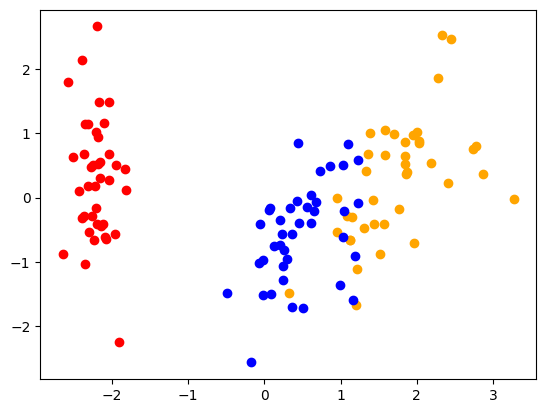

In [25]:
import matplotlib.pyplot as plt

colors= ["red","blue","orange"]

for i,label in enumerate(y_train):
    plt.scatter(X_lowered[i,0], X_lowered[i,1],color=colors[label])


In [26]:
X_lowered[:,0]

array([-2.35430673,  0.32811646,  1.2290844 , -2.19452009,  0.24248823,
        1.52294955,  0.25815436,  1.08813566,  2.7816565 ,  2.45214546,
        2.73500972,  0.64451798, -0.17735004,  0.12752389,  0.30008117,
       -2.26948632, -2.31638839,  1.96442486,  1.33662596, -1.82655915,
        1.19203651, -2.35781737,  2.32990455, -1.96744528, -0.02337536,
        1.4200781 ,  1.57165511, -2.04514806,  0.95404926, -2.27539463,
       -2.18526009,  0.44995103,  0.60933618, -2.20443687,  1.84152717,
        1.38013471, -0.07695984, -0.01812383,  1.9993851 ,  0.73415469,
       -2.43732364,  1.09521956, -2.17593748,  2.40838143, -2.09643121,
       -2.17944813,  1.12813377, -2.21292277, -1.91001128, -2.2338067 ,
       -2.08486989, -0.05340197,  1.84687504,  0.36351982, -2.25391653,
        0.94659275,  0.23136212,  1.58358904, -2.39847225,  1.12813377,
       -2.03532762,  0.35580802,  1.21997546, -2.22078077,  1.03054272,
        0.24351762,  2.86980762,  0.33622975,  1.04875271,  1.58

In [27]:
# 3. Create pipeline (scaling + SVM)
pipe = Pipeline([
    ('scaler', StandardScaler()),  # SVM is sensitive to feature scale
    ('svm', SVC())                 
])

# 4. Hyperparameter tuning with cross-validation
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.01, 0.1, 1],  # only for RBF kernel
    'svm__kernel': ['rbf', 'linear']  # can also try 'poly', 'sigmoid'
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


Best parameters: {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}


In [28]:

# 5. Evaluate final model on test set
best_model = grid_search.best_estimator_
best_model

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,0.1
,kernel,'linear'
,degree,3
,gamma,0.01


In [29]:

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [30]:
y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

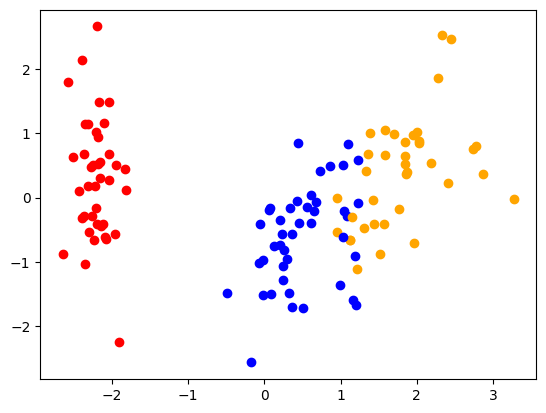

In [33]:
import matplotlib.pyplot as plt

colors= ["red","blue","orange"]

y_pred_train = best_model.predict(X_train)

for i,label in enumerate(y_pred_train):
    plt.scatter(X_lowered[i,0], X_lowered[i,1],color=colors[label])
